In [23]:
import pandas as pd
import matplotlib.pyplot as plt
file='Orders.xlsx'
customers=pd.read_excel(file,sheet_name='Customers')
df1=pd.DataFrame(customers)
print('\nCustomers')
print(df1)
products=pd.read_excel(file,sheet_name='Products')
df2=pd.DataFrame(products)
print('\nProducts')
print(df2)
orders=pd.read_excel(file,sheet_name='Orders')
df3=pd.DataFrame(orders)
print('\nProducts')
print(df3)


Customers
    Customer_ID          Name       City
0             1    Customer_1  Bangalore
1             2    Customer_2  Hyderabad
2             3    Customer_3      Kochi
3             4    Customer_4  Bangalore
4             5    Customer_5  Bangalore
..          ...           ...        ...
95           96   Customer_96    Chennai
96           97   Customer_97    Chennai
97           98   Customer_98  Hyderabad
98           99   Customer_99    Chennai
99          100  Customer_100      Kochi

[100 rows x 3 columns]

Products
    Product_ID Product_Name     Category  Price
0            1    Product_1         Home   4959
1            2    Product_2     Clothing    479
2            3    Product_3     Clothing    592
3            4    Product_4     Clothing   2162
4            5    Product_5     Clothing   3984
5            6    Product_6     Clothing    164
6            7    Product_7     Clothing   2668
7            8    Product_8         Home   2127
8            9    Product_9    

In [47]:
print('First five rows of customer dataset:\n',df1.head())
print('First five rows of product dataset:\n',df2.head())
print('First five rows of order dataset:\n',df3.head())

First five rows of customer dataset:
    Customer_ID        Name       City
0            1  Customer_1  Bangalore
1            2  Customer_2  Hyderabad
2            3  Customer_3      Kochi
3            4  Customer_4  Bangalore
4            5  Customer_5  Bangalore
First five rows of product dataset:
    Product_ID Product_Name  Category  Price
0           1    Product_1      Home   4959
1           2    Product_2  Clothing    479
2           3    Product_3  Clothing    592
3           4    Product_4  Clothing   2162
4           5    Product_5  Clothing   3984
First five rows of order dataset:
    Order_ID  Customer_ID  Product_ID  Quantity Order_Date
0         1           23           2         2 2023-11-22
1         2           62           2         1 2023-04-28
2         3           88          19         3 2023-11-20
3         4           37          17         1 2023-10-02
4         5           99          20         1 2023-07-31


In [24]:
merged = (
    df1
    .merge(df3, on='Customer_ID', how='left')
    .merge(df2, on='Product_ID', how='left')
)
print(merged.head())

   Customer_ID        Name       City  Order_ID  Product_ID  Quantity  \
0            1  Customer_1  Bangalore      15.0         5.0       4.0   
1            1  Customer_1  Bangalore      61.0         7.0       4.0   
2            1  Customer_1  Bangalore      99.0        14.0       3.0   
3            1  Customer_1  Bangalore     143.0         9.0       1.0   
4            1  Customer_1  Bangalore     159.0         7.0       1.0   

  Order_Date Product_Name     Category   Price  
0 2023-02-07    Product_5     Clothing  3984.0  
1 2023-10-18    Product_7     Clothing  2668.0  
2 2023-06-06   Product_14  Electronics  3661.0  
3 2023-09-11    Product_9         Home  2795.0  
4 2023-04-14    Product_7     Clothing  2668.0  


In [25]:
merged['Sales'] = merged['Quantity'] * merged['Price']
print(merged.head())

   Customer_ID        Name       City  Order_ID  Product_ID  Quantity  \
0            1  Customer_1  Bangalore      15.0         5.0       4.0   
1            1  Customer_1  Bangalore      61.0         7.0       4.0   
2            1  Customer_1  Bangalore      99.0        14.0       3.0   
3            1  Customer_1  Bangalore     143.0         9.0       1.0   
4            1  Customer_1  Bangalore     159.0         7.0       1.0   

  Order_Date Product_Name     Category   Price    Sales  
0 2023-02-07    Product_5     Clothing  3984.0  15936.0  
1 2023-10-18    Product_7     Clothing  2668.0  10672.0  
2 2023-06-06   Product_14  Electronics  3661.0  10983.0  
3 2023-09-11    Product_9         Home  2795.0   2795.0  
4 2023-04-14    Product_7     Clothing  2668.0   2668.0  


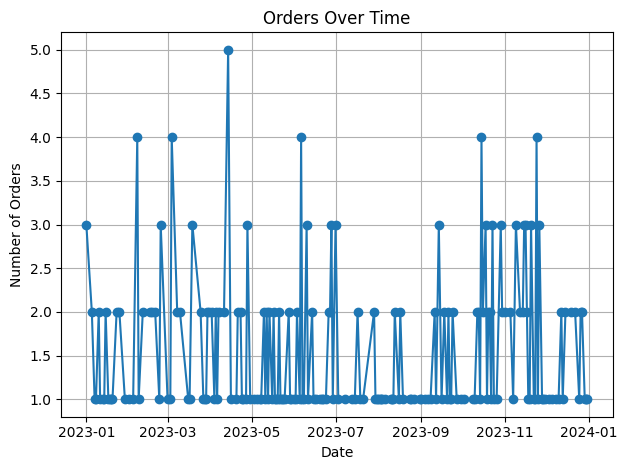

In [26]:
df3['Order_Date'] = pd.to_datetime(df3['Order_Date'])
orders_per_day = df3.groupby('Order_Date').size()
plt.plot(orders_per_day.index,orders_per_day.values,marker='o')
plt.title('Orders Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.tight_layout()
plt.show()

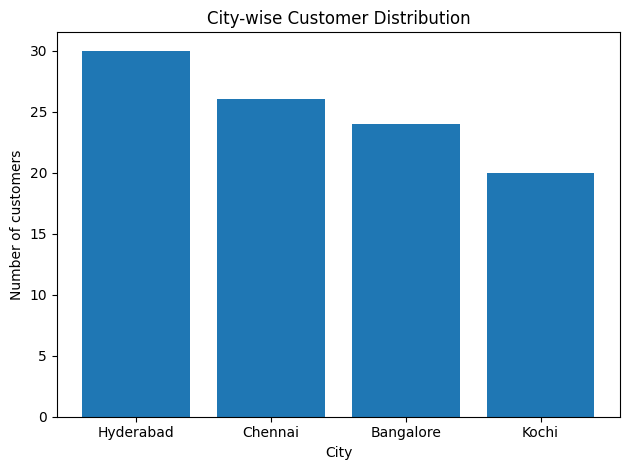

In [27]:
city_counts = df1['City'].value_counts()
plt.bar(city_counts.index,city_counts.values)
plt.xlabel('City')
plt.ylabel('Number of customers')
plt.title('City-wise Customer Distribution')
plt.tight_layout()
plt.show()

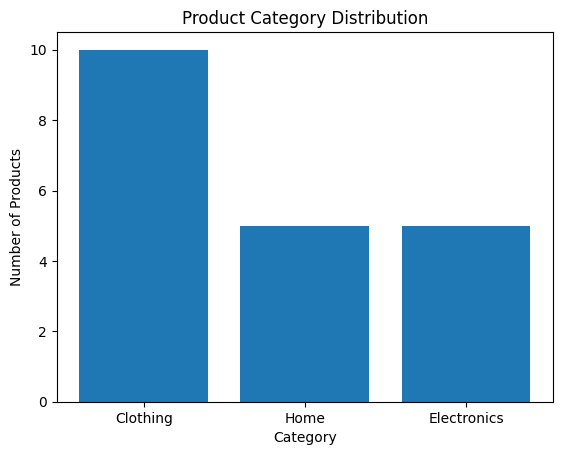

In [28]:
category_counts=df2['Category'].value_counts()
plt.bar(category_counts.index,category_counts.values)
plt.title('Product Category Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.show()

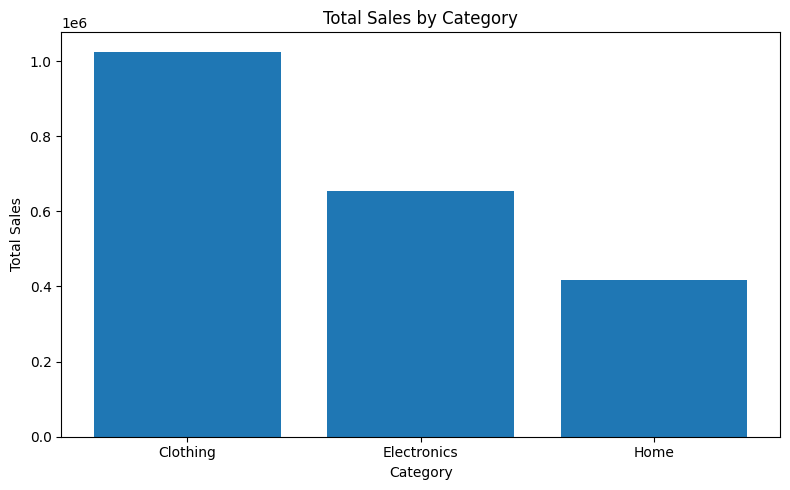

In [29]:
sales_by_category=(merged.groupby('Category')['Sales'].sum())
plt.figure(figsize=(8,5))
plt.bar(sales_by_category.index,sales_by_category.values)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

Product_Name
Product_1     247950.0
Product_5     243024.0
Product_13    210404.0
Product_12    198402.0
Product_18    189050.0
Product_16    166348.0
Product_19    144180.0
Product_20    140940.0
Product_9      89440.0
Product_4      75670.0
Name: Sales, dtype: float64


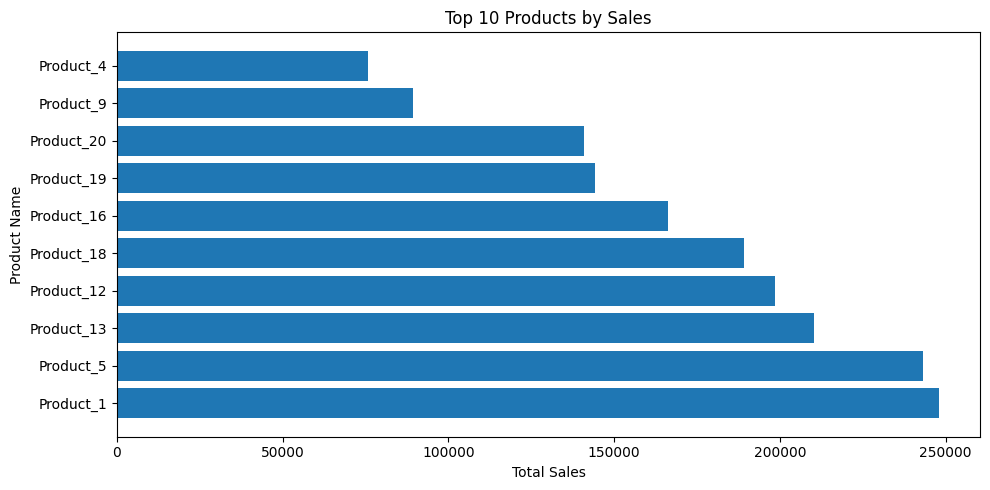

In [30]:
top_products = (merged.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False))
print(top_products.head(10))
top10=top_products.head(10)
plt.figure(figsize=(10,5))
plt.barh(top10.index,top10.values)
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

Name
Customer_99    9
Customer_32    7
Customer_24    7
Customer_33    7
Customer_62    7
              ..
Customer_74    1
Customer_73    1
Customer_81    1
Customer_91    1
Customer_85    1
Length: 100, dtype: int64


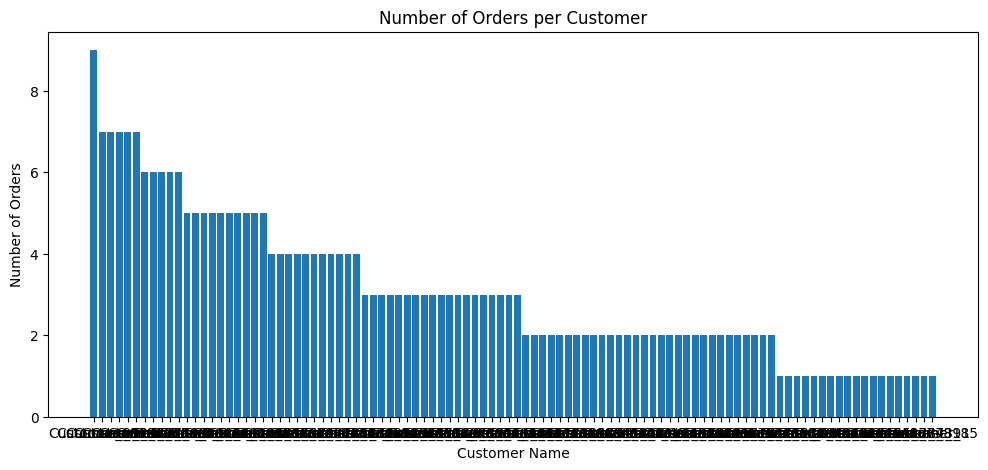

In [31]:
customer_orders = (merged.groupby('Name').size().sort_values(ascending=False))
print(customer_orders)
plt.figure(figsize=(12,5))
plt.bar( customer_orders.index, customer_orders.values)
plt.title('Number of Orders per Customer')
plt.xlabel('Customer Name')
plt.ylabel('Number of Orders')
plt.show()

Product_Name
Product_5     61.0
Product_16    52.0
Product_1     50.0
Product_10    47.0
Product_13    46.0
Product_19    45.0
Product_17    44.0
Product_12    43.0
Product_3     41.0
Product_18    38.0
Product_4     35.0
Product_9     32.0
Product_20    30.0
Product_6     29.0
Product_7     26.0
Product_2     26.0
Product_8     26.0
Product_11    25.0
Product_15    25.0
Product_14    18.0
Name: Quantity, dtype: float64


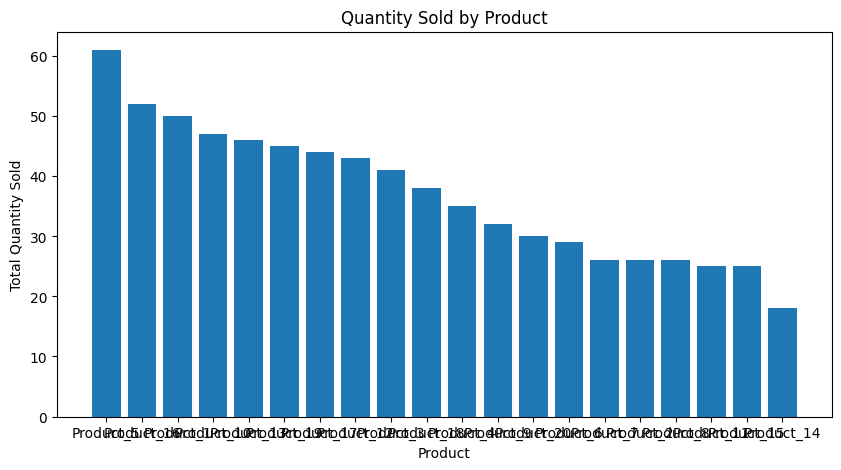

In [32]:
quantity_by_product = (merged.groupby('Product_Name')['Quantity'].sum().sort_values(ascending=False))
print(quantity_by_product)
plt.figure(figsize=(10,5))
plt.bar(quantity_by_product.index,quantity_by_product.values)
plt.title('Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.show()

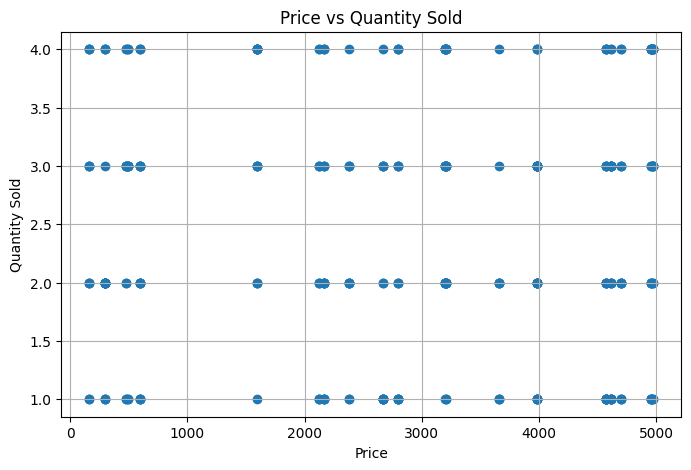

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(merged['Price'],merged['Quantity'])
plt.title('Price vs Quantity Sold')
plt.xlabel('Price')
plt.ylabel('Quantity Sold')
plt.grid(True)
plt.show()

Month
2023-01    202206.0
2023-02    141852.0
2023-03    180243.0
2023-04    138766.0
2023-05    204960.0
2023-06    200691.0
2023-07    123316.0
2023-08     85780.0
2023-09    173231.0
2023-10    212652.0
2023-11    297718.0
2023-12    135933.0
Freq: M, Name: Sales, dtype: float64


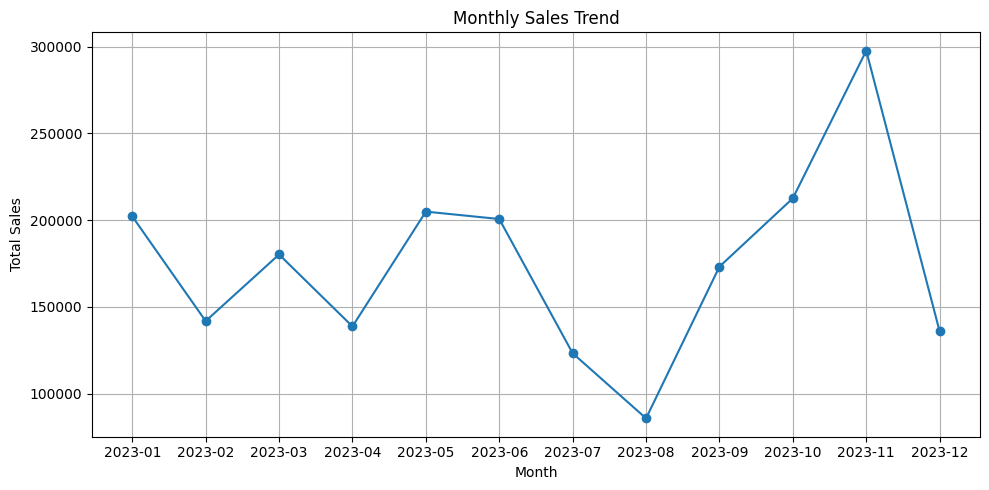

In [34]:
merged['Month'] = merged['Order_Date'].dt.to_period('M')
monthly_sales = (merged.groupby('Month')['Sales'].sum())
print(monthly_sales)
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index.astype(str),monthly_sales.values,marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

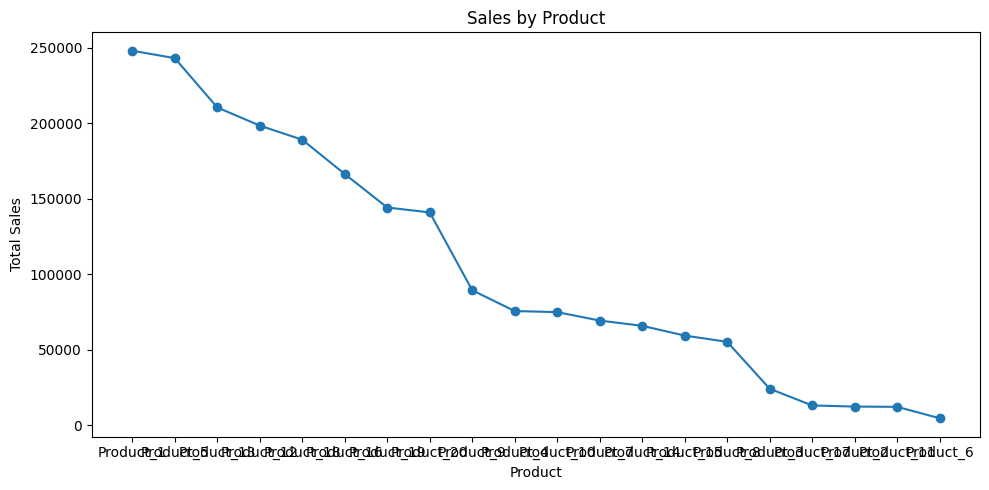

In [35]:
plt.figure(figsize=(10,5))
plt.plot(top_products.index,top_products.values,marker='o')
plt.title('Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


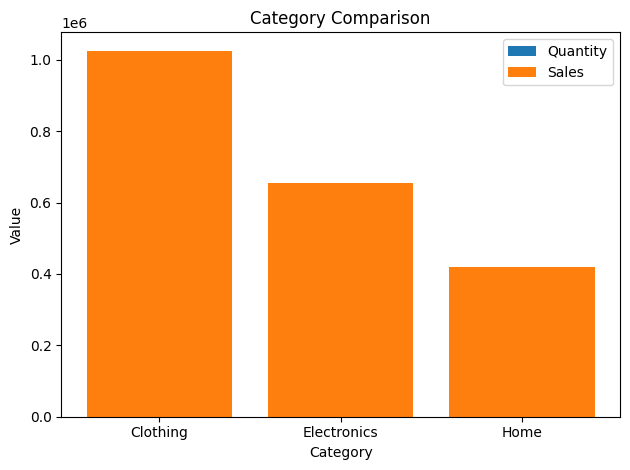

In [36]:
category_qty=merged.groupby('Category')['Quantity'].sum()
category_sales=merged.groupby('Category')['Sales'].sum()
x=range(len(category_qty))
plt.bar( x, category_qty.values, label='Quantity')
plt.bar(x,category_sales.values,bottom=category_qty.values,label='Sales')
plt.xticks(x, category_qty.index)
plt.title('Category Comparison')
plt.xlabel('Category')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

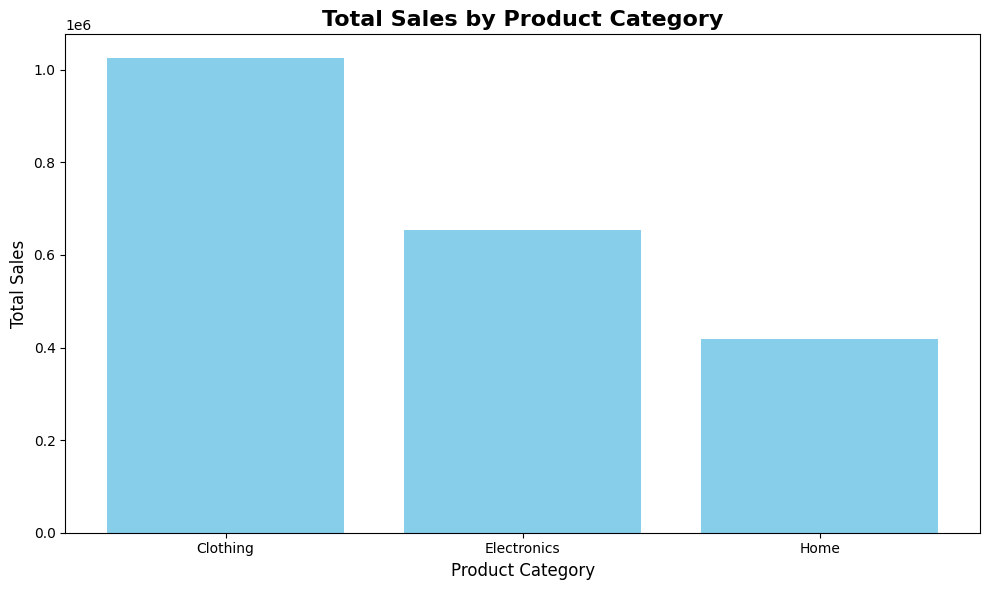

In [37]:
plt.figure(figsize=(10,6))
plt.bar( sales_by_category.index,sales_by_category.values,color='skyblue')
plt.title('Total Sales by Product Category',fontsize=16,fontweight='bold')
plt.xlabel('Product Category',fontsize=12)
plt.ylabel('Total Sales',fontsize=12)
plt.tight_layout()
plt.show()

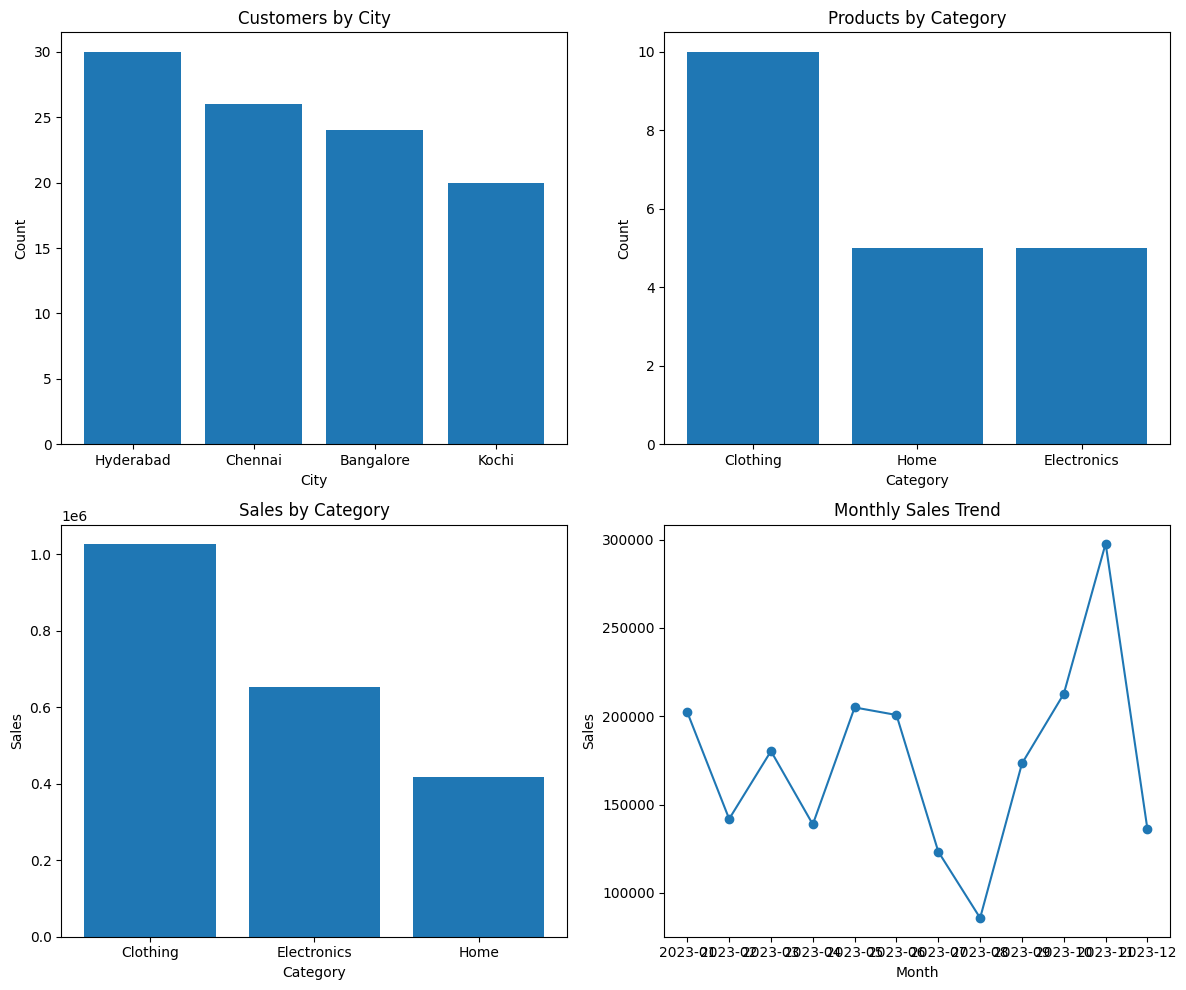

In [38]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
# Chart 1: Customers by City
ax[0,0].bar(city_counts.index,city_counts.values)
ax[0,0].set_title('Customers by City')
ax[0,0].set_xlabel('City')
ax[0,0].set_ylabel('Count')

# Chart 2: Products by Category
ax[0,1].bar(category_counts.index,category_counts.values)
ax[0,1].set_title('Products by Category')
ax[0,1].set_xlabel('Category')
ax[0,1].set_ylabel('Count')

# Chart 3: Sales by Category
ax[1,0].bar(sales_by_category.index,sales_by_category.values)
ax[1,0].set_title('Sales by Category')
ax[1,0].set_xlabel('Category')
ax[1,0].set_ylabel('Sales')

# Chart 4: Monthly Sales Trend
ax[1,1].plot(monthly_sales.index.astype(str),monthly_sales.values,marker='o')
ax[1,1].set_title('Monthly Sales Trend')
ax[1,1].set_xlabel('Month')
ax[1,1].set_ylabel('Sales')
plt.tight_layout()
plt.show()

In [39]:
print(merged.isnull().sum())

Customer_ID     0
Name            0
City            0
Order_ID        4
Product_ID      4
Quantity        4
Order_Date      4
Product_Name    4
Category        4
Price           4
Sales           4
Month           4
dtype: int64


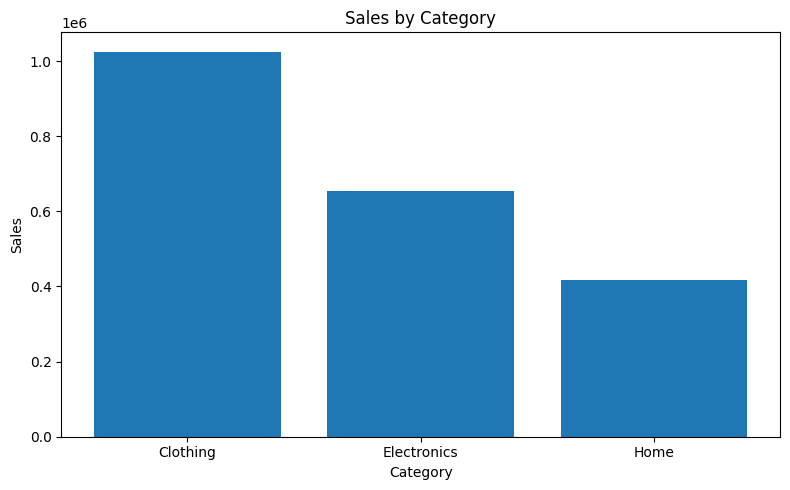

In [40]:
plt.figure(figsize=(8,5))
plt.bar(sales_by_category.index,sales_by_category.values)
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.tight_layout()
# Saved in PNG format
plt.savefig('sales_by_category.png')
# Saved in PDF format
plt.savefig('sales_by_category.pdf')
plt.show()

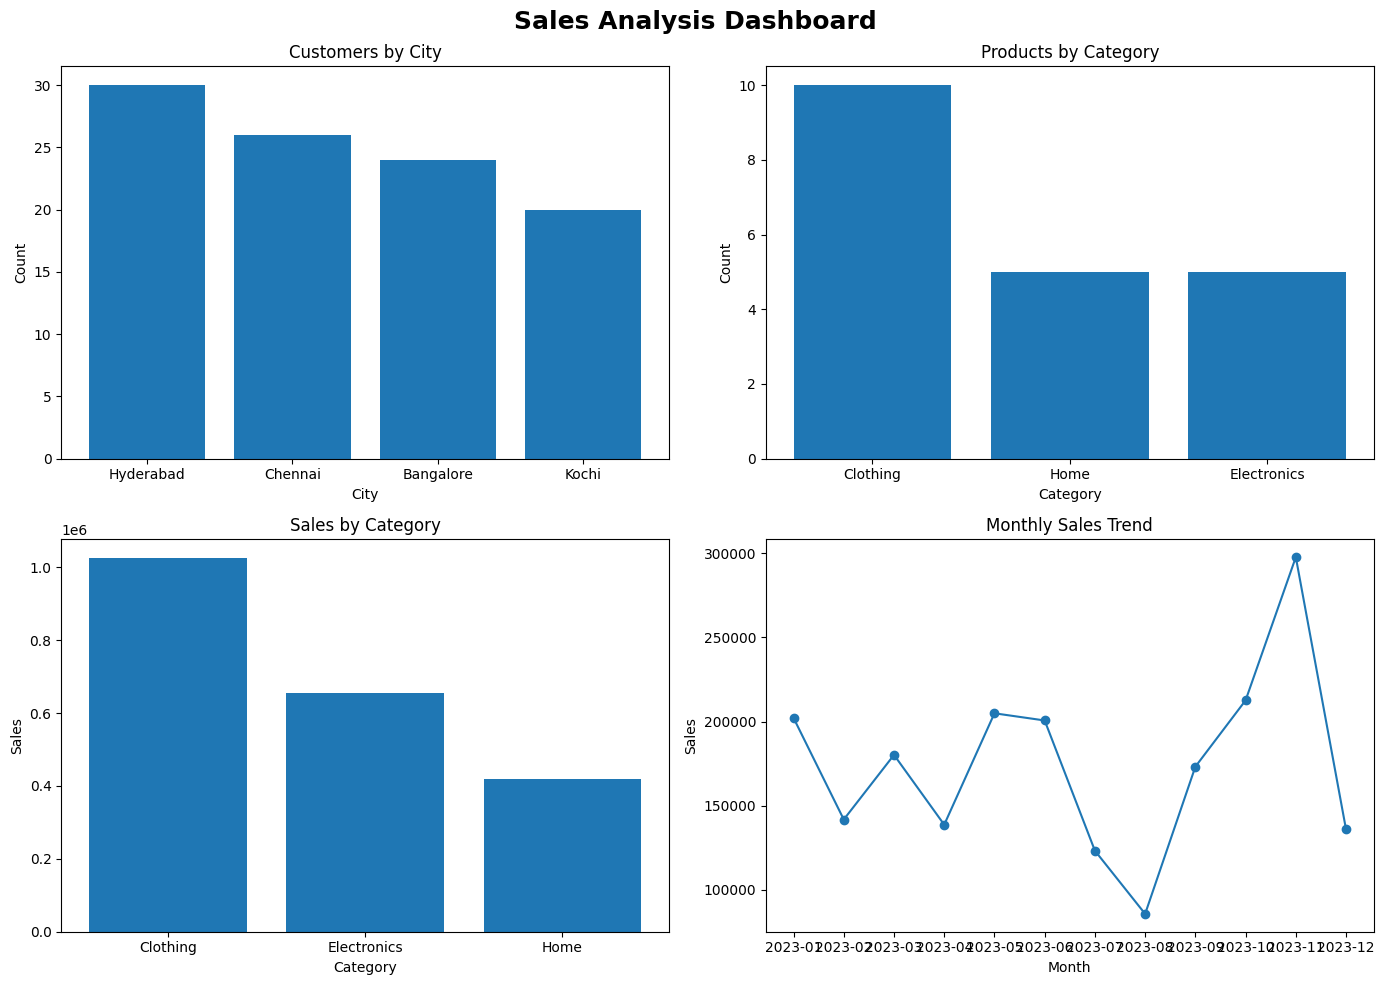

In [41]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Customers by City
ax[0,0].bar(city_counts.index,city_counts.values)
ax[0,0].set_title('Customers by City')
ax[0,0].set_xlabel('City')
ax[0,0].set_ylabel('Count')

# 2. Products by Category

ax[0,1].bar(category_counts.index,category_counts.values)
ax[0,1].set_title('Products by Category')
ax[0,1].set_xlabel('Category')
ax[0,1].set_ylabel('Count')

# 3. Sales by Category
ax[1,0].bar(sales_by_category.index,sales_by_category.values)
ax[1,0].set_title('Sales by Category')
ax[1,0].set_xlabel('Category')
ax[1,0].set_ylabel('Sales')

# 4. Monthly Sales Trend
ax[1,1].plot(monthly_sales.index.astype(str),monthly_sales.values, marker='o')
ax[1,1].set_title('Monthly Sales Trend')
ax[1,1].set_xlabel('Month')
ax[1,1].set_ylabel('Sales')

# Dashboard Title
plt.suptitle('Sales Analysis Dashboard',fontsize=18,fontweight='bold')
plt.tight_layout()
plt.show()

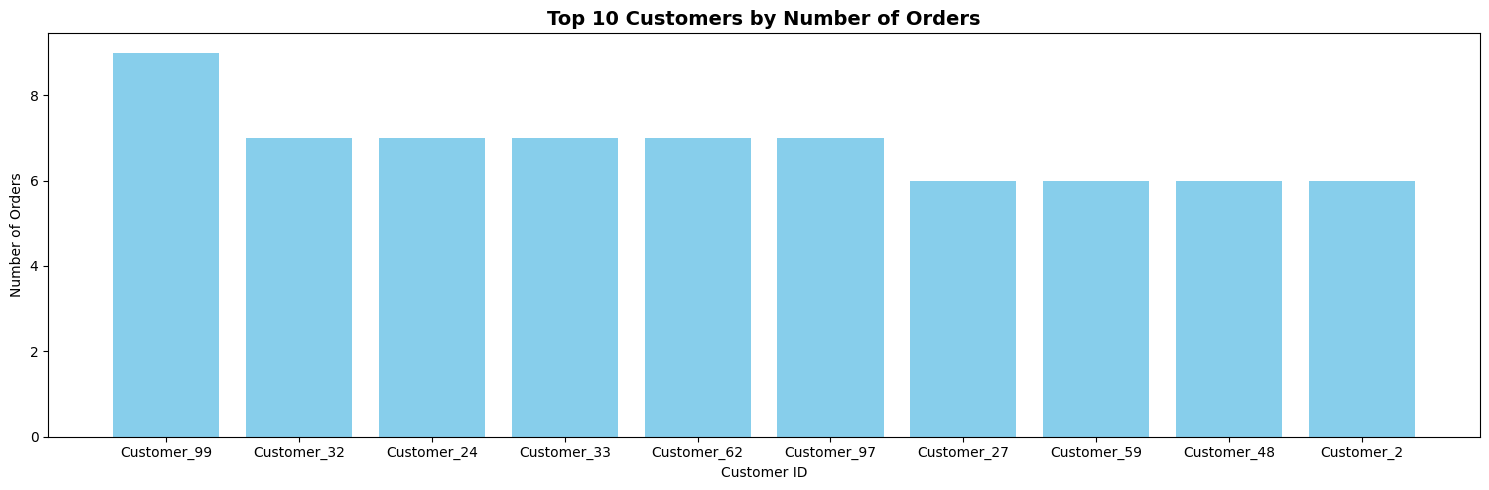

In [43]:
top10_customers = customer_orders.head(10)
plt.figure(figsize=(15,5))
plt.bar(top10_customers.index,top10_customers.values,color='skyblue')
plt.title('Top 10 Customers by Number of Orders',fontsize=14,fontweight='bold')
plt.xlabel('Customer ID')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()